# Weaver eval analysis

Analysis of the offline eval harness output (`scripts/run_evals.py` -> `evals/results/<UTC>/runs.csv`).

Each hypothesis maps to columns already produced by `services/telemetry.py`. All metrics are objective: token counts, structural counts, validation booleans, and reference-based deltas vs the gold workflows in `prompts/workflows.json`. No LLM-as-judge, no Likert.

**Held-out evaluation:** the 3 examples in `prompts/few_shot_examples.json` are sent with every LLM request, so the 3 fixtures that also appear there are contaminated — the model sees their gold answer in its prompt. The harness now excludes them by default and tags every row with `held_out`. All hypothesis sections below use **held-out fixtures only**; the contamination section quantifies the gap for runs that include seen fixtures.

## Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# Visual defaults tuned for a notebook with 20 fixtures and 3 runs each.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.frameon": False,
})
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)


def short_name(name: str, n: int = 32) -> str:
    """Truncate fixture names so they fit on plot axes."""
    name = str(name)
    return name if len(name) <= n else name[: n - 1].rstrip() + "\u2026"


REPO_ROOT = Path.cwd().parent if Path.cwd().name in ("notebooks", "scripts") else Path.cwd()
RESULTS_ROOT = REPO_ROOT / "evals" / "results"

available = sorted([p for p in RESULTS_ROOT.iterdir() if (p / "runs.csv").exists()])
print(f"Found {len(available)} run(s) with data:")
for p in available:
    print(" -", p.name)

# Pick the most recent non-empty run by default; override below to pin a specific timestamp.
RUN_DIR = available[-1]
print("\nUsing:", RUN_DIR.name)

Found 8 run(s) with data:
 - 2026-05-21T14-56-03Z
 - 2026-05-21T15-13-23Z
 - 2026-05-23T16-33-26Z
 - 2026-05-24T12-21-37Z
 - 2026-06-03T13-46-01Z
 - 2026-06-07T13-25-30Z
 - 2026-06-07T13-51-54Z
 - 2026-06-07T14-00-23Z

Using: 2026-06-07T14-00-23Z


In [2]:
df = pd.read_csv(RUN_DIR / "runs.csv")
summary = pd.read_csv(RUN_DIR / "summary.csv")
headline = json.loads((RUN_DIR / "summary.json").read_text())

# errors and element_type_counts arrive as JSON strings; decode for analysis.
df["errors"] = df["errors"].fillna("[]").apply(json.loads)
df["element_type_counts"] = df["element_type_counts"].fillna("{}").apply(json.loads)

# Short labels for plotting.
df["fixture"] = df["process_name"].map(short_name)

print("Headline rates:", headline["rates"])
print("Total tokens:", headline["totals"]["total_tokens"], "  Wall:", headline["wall_seconds"], "s")
print("\nFixtures (n_runs each):")
print(df.groupby("process_name").size().to_string())
df.head()

Headline rates: {'parsed_ok': 1.0, 'schema_pass': 1.0, 'semantic_pass': 0.8824}
Total tokens: 380613   Wall: 342.09 s

Fixtures (n_runs each):
process_name
Beam Automated Scribe for Community Care Worker      3
Civic AI Casework Triage                             3
Civic AI Congressional Correspondence                3
Civic AI Constituent Sentiment Analysis              3
Civic AI Social Media Drafting                       3
Claim Generative Engine Optimization for Webpages    3
CrowdAI Fireline Spot Fire Identification            3
Indian Railway Expenditure Agent                     3
Indian Railway Smart AI Assistant                    3
Laurettaio Video Anomaly Detector                    3
Mastercard Transaction Risk Monitoring               3
NHS Automated Medical Triage                         3
NHS Automated Scribe for Clinician                   3
NHS Blood Test Lab Report Processing                 3
NHS Medical Bone Imaging Pathology Detection         3
Sanome Clinical Dec

,process_name,run_idx,held_out,parsed_ok,schema_pass,semantic_pass,errors,finish_reason,api_error,prompt_tokens,completion_tokens,total_tokens,latency_ms,num_elements,num_flows,element_type_counts,num_final_outcomes,branching_factor,max_path_length,has_cycle,element_count_delta,flow_count_delta,gold_type_coverage,structural_similarity,type_distribution_similarity,name_semantic_similarity,name_type_semantic_similarity,aligned_type_accuracy,fixture
0,Beam Automated Scribe for Community Care Worker,0,True,True,True,True,[],stop,NaN,3806,4868,8674,34910,16,21,"{'humanSource': 2, 'ui': 1, 'decisionPoint': 2...",2,2.5,NaN,True,-2,0,0.8889,0.8952,0.8995,0.7484,0.7443,0.6875,Beam Automated Scribe for Commu…
1,Beam Automated Scribe for Community Care Worker,1,True,True,True,True,[],stop,NaN,3806,4212,8018,33371,16,20,"{'humanSource': 1, 'ui': 2, 'inputOutput': 3, ...",2,3.0,NaN,True,-2,-1,0.8889,0.8929,0.8737,0.6354,0.6732,0.6875,Beam Automated Scribe for Commu…
2,Beam Automated Scribe for Community Care Worker,2,True,True,True,True,[],stop,NaN,3806,3809,7615,27232,18,22,"{'humanSource': 2, 'inputOutput': 3, 'ui': 2, ...",1,3.5,NaN,True,0,1,0.8889,0.9567,0.8882,0.7524,0.7788,0.6667,Beam Automated Scribe for Commu…
3,Civic AI Casework Triage,0,True,True,True,True,[],stop,NaN,3829,5991,9820,46908,21,24,"{'humanSource': 1, 'inputOutput': 7, 'fixedAIM...",2,3.0,NaN,True,6,8,1.0000,0.7588,0.9242,0.5032,0.5760,0.6667,Civic AI Casework Triage
4,Civic AI Casework Triage,1,True,True,True,True,[],stop,NaN,3829,4641,8470,36704,18,21,"{'inputOutput': 8, 'fixedAIModel': 3, 'humanSo...",2,3.0,NaN,True,3,5,1.0000,0.8248,0.9532,0.5421,0.6397,0.8000,Civic AI Casework Triage


## Held-out filtering — drop few-shot (seen) fixtures

The 3 few-shot examples are in the prompt of every request, so eval runs on those same fixtures measure memorization, not generalization. Older `runs.csv` files predate the `held_out` column, so it is derived here from `few_shot_examples.json` when missing.

In [3]:
# Identify fixtures whose gold answer the model sees in its prompt.
few_shot = json.loads((REPO_ROOT / "prompts" / "few_shot_examples.json").read_text(encoding="utf-8"))
SEEN_NAMES = {ex["assistant"]["process_name"] for ex in few_shot}
print(f"Few-shot (seen) fixtures: {sorted(SEEN_NAMES)}")

# Back-compat: derive held_out for runs.csv files written before the column existed.
if "held_out" not in df.columns:
    df["held_out"] = ~df["process_name"].isin(SEEN_NAMES)
    print("\nNote: held_out column derived from few_shot_examples.json (old runs.csv).")

df_all = df.copy()          # everything, for the contamination comparison below
df_seen = df_all[~df_all["held_out"]]
df = df_all[df_all["held_out"]].reset_index(drop=True)

print(f"\nRows: {len(df_all)} total -> {len(df)} held-out ({df['process_name'].nunique()} fixtures), "
      f"{len(df_seen)} seen ({df_seen['process_name'].nunique()} fixtures) excluded from hypothesis sections.")

# Honest headline rates — held-out only. These supersede summary.json rates
# for any run that contained seen fixtures.
held_out_rates = {
    "parsed_ok": df["parsed_ok"].mean(),
    "schema_pass": df["schema_pass"].mean(),
    "semantic_pass": df["semantic_pass"].mean(),
}
print("Held-out headline rates:", {k: round(v, 4) for k, v in held_out_rates.items()})

Few-shot (seen) fixtures: ['CrowdAI Dented Can Identification', 'KyklosTech Guideline-Integrated Decision Engine', 'USA Federal Employee Award Writing']

Rows: 51 total -> 51 held-out (17 fixtures), 0 seen (0 fixtures) excluded from hypothesis sections.
Held-out headline rates: {'parsed_ok': np.float64(1.0), 'schema_pass': np.float64(1.0), 'semantic_pass': np.float64(0.8824)}


### Contamination check: seen vs held-out

If the run includes seen fixtures (old runs, or `--include-seen`), compare reference metrics between the two groups. A large gap is direct evidence that few-shot leakage inflates scores — and the methodological justification for reporting held-out numbers in the dissertation.

In [4]:
# Fidelity axes (defined once, reused below). Semantic metrics are NaN when
# sentence-transformers is not installed, so always filter to present+non-null.
SHAPE_METRICS = ["structural_similarity", "type_distribution_similarity"]
MEANING_METRICS = ["name_semantic_similarity", "name_type_semantic_similarity", "aligned_type_accuracy"]


def present(cols, frame):
    return [c for c in cols if c in frame.columns and frame[c].notna().any()]


CONTAM_METRICS = present(["semantic_pass", "gold_type_coverage", *SHAPE_METRICS, *MEANING_METRICS], df_all)

if df_seen.empty:
    print("This run contains no seen fixtures (harness excluded them) — nothing to compare.")
else:
    comp = (
        df_all.assign(group=np.where(df_all["held_out"], "held-out", "seen (few-shot)"))
        .groupby("group")[CONTAM_METRICS]
        .agg(["mean", "std", "count"])
        .round(3)
    )
    display(comp)

    means = (
        df_all.assign(group=np.where(df_all["held_out"], "held-out", "seen (few-shot)"))
        .groupby("group")[CONTAM_METRICS]
        .mean()
        .T
    )
    fig, ax = plt.subplots(figsize=(8, 4))
    means.plot.barh(ax=ax, color={"seen (few-shot)": "#d62728", "held-out": "#4c78a8"},
                    edgecolor="white")
    ax.set_xlim(0, 1.05)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
    ax.set_xlabel("Mean score")
    ax.set_title("Few-shot contamination: seen fixtures outscore held-out ones")
    ax.legend(title="", loc="lower right")
    plt.tight_layout()
    plt.show()

    # Mann-Whitney U (non-parametric, unequal group sizes) per metric.
    for m in CONTAM_METRICS:
        u = stats.mannwhitneyu(
            df_seen[m].dropna().astype(float), df[m].dropna().astype(float), alternative="greater"
        )
        print(f"{m:34s} seen>{'held-out':9s} U={u.statistic:.0f}  p={u.pvalue:.4f}")

This run contains no seen fixtures (harness excluded them) — nothing to compare.


## Gold reference shape

Load the gold traces from `prompts/workflows.json` so we can compare prediction sizes to ground-truth sizes per fixture.

In [5]:
gold = json.loads((REPO_ROOT / "prompts" / "workflows.json").read_text(encoding="utf-8"))
gold_df = pd.DataFrame([
    {
        "process_name": w["assistant"]["process_name"],
        "gold_elements": len(w["assistant"]["elements"]),
        "gold_flows": len(w["assistant"]["flows"]),
        "gold_types": len({e["type"] for e in w["assistant"]["elements"]}),
        "gold_final_outcomes": sum(1 for e in w["assistant"]["elements"] if e["type"] == "finalOutcome"),
    }
    for w in gold
])
df = df.merge(gold_df, on="process_name", how="left")
gold_df[gold_df["process_name"].isin(df["process_name"].unique())]

,process_name,gold_elements,gold_flows,gold_types,gold_final_outcomes
0,Beam Automated Scribe for Community Care Worker,18,21,9,2
1,Civic AI Casework Triage,15,16,7,1
2,Civic AI Congressional Correspondence,14,15,7,1
3,Civic AI Constituent Sentiment Analysis,6,5,4,1
4,Civic AI Social Media Drafting,8,8,7,1
5,Claim Generative Engine Optimization for Webpages,12,13,8,1
7,CrowdAI Fireline Spot Fire Identification,12,13,8,1
8,Indian Railway Expenditure Agent,8,8,7,1
9,Indian Railway Smart AI Assistant,8,8,7,1
11,Laurettaio Video Anomaly Detector,16,16,8,2


## H1 - Failures concentrate at the semantic layer

**Claim:** Pass rates follow the order parse >= schema >= semantic, with most failures at the semantic layer (orphan/dead-end nodes, multi-entry, terminal-with-outgoing).

**Why it matters:** If parse and schema are near-perfect but semantic fails, prompt edits + post-validation are the leverage point, not retraining or a different model.

,tier,pass_rate,n_fail
0,parsed_ok,1.000000,0
1,schema_pass,1.000000,0
2,semantic_pass,0.882353,6


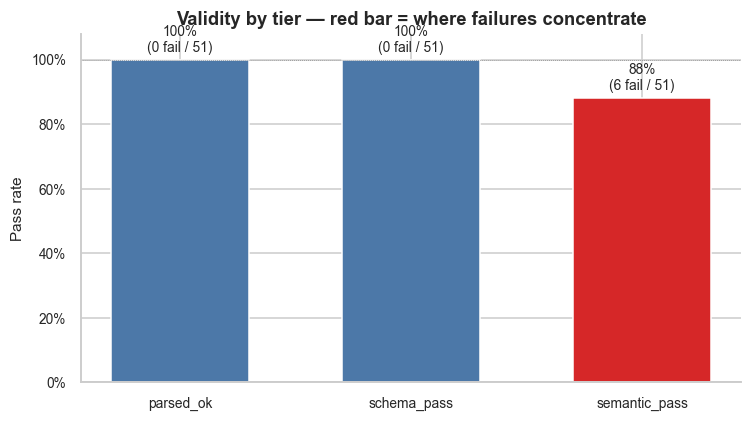

In [6]:
tiers = pd.DataFrame({
    "tier": ["parsed_ok", "schema_pass", "semantic_pass"],
    "pass_rate": [df["parsed_ok"].mean(), df["schema_pass"].mean(), df["semantic_pass"].mean()],
    "n_fail": [(~df["parsed_ok"]).sum(), (~df["schema_pass"]).sum(), (~df["semantic_pass"]).sum()],
})
display(tiers)

fig, ax = plt.subplots(figsize=(7, 4))
# Color the weakest tier red; the rest neutral grey.
weakest = tiers["pass_rate"].idxmin()
colors = ["#4c78a8" if i != weakest else "#d62728" for i in range(len(tiers))]
bars = ax.bar(tiers["tier"], tiers["pass_rate"], color=colors, edgecolor="white", width=0.6)

ax.set_ylim(0, 1.08)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.set_ylabel("Pass rate")
ax.set_xlabel("")
ax.set_title("Validity by tier — red bar = where failures concentrate")
ax.axhline(1.0, color="grey", linewidth=0.5, linestyle=":")

for bar, (_, r) in zip(bars, tiers.iterrows()):
    label = f"{r['pass_rate']:.0%}\n({r['n_fail']} fail / {len(df)})"
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
            label, ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

,n
family,
dead_end,5
multi_entry,4


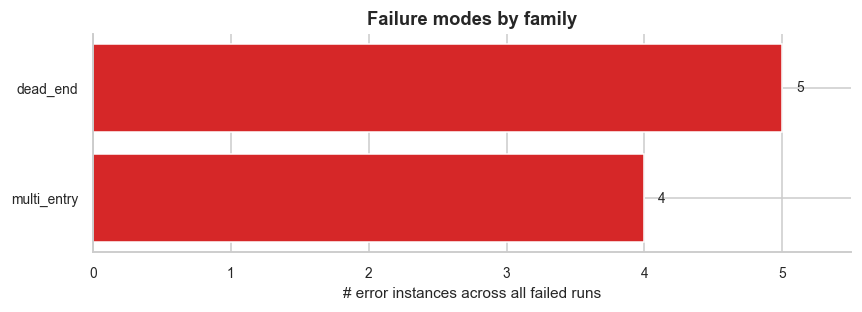

In [7]:
# Semantic error taxonomy: which error families fire most often?
def classify(msg: str) -> str:
    m = msg.lower()
    if "dead end" in m or "no outgoing flows" in m:
        return "dead_end"
    if "multiple entry" in m or "entry point" in m:
        return "multi_entry"
    if "terminal node" in m and "outgoing" in m:
        return "terminal_with_outgoing"
    if "schema error" in m or "additional properties" in m:
        return "schema"
    if "flow ref" in m or ("invalid" in m and "id" in m):
        return "bad_flow_ref"
    if "duplicate" in m:
        return "duplicate_id"
    return "other"

err_rows = []
for _, r in df[~df["semantic_pass"] | ~df["schema_pass"]].iterrows():
    for e in r["errors"]:
        err_rows.append({"process_name": r["process_name"], "family": classify(str(e)), "message": str(e)})
errs = pd.DataFrame(err_rows)

if not errs.empty:
    fam = errs.groupby("family").size().sort_values(ascending=True).rename("n")
    display(fam.sort_values(ascending=False).to_frame())

    fig, ax = plt.subplots(figsize=(8, max(3, 0.5 * len(fam) + 1)))
    bars = ax.barh(fam.index, fam.values, color="#d62728", edgecolor="white")
    ax.set_xlabel("# error instances across all failed runs")
    ax.set_title("Failure modes by family")
    for bar, v in zip(bars, fam.values):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                str(int(v)), va="center", fontsize=9)
    ax.margins(x=0.1)
    plt.tight_layout()
    plt.show()
else:
    print("No failures in this run.")

## H2 - Predictions inflate vs gold (over-generation)

**Claim:** `element_count_delta = predicted - gold` is positive on average, meaning the LLM elaborates user descriptions into more nodes than the gold trace contains.

**Why it matters:** If true, the post-edit human cost is *trimming* spurious nodes, not adding missing ones. That informs the UI affordances we should prioritize.

,element_count_delta,flow_count_delta,gold_elements,gold_flows,element_ratio
process_name,,,,,
Beam Automated Scribe for Community Care Worker,-1.33,0.00,18.0,21.0,0.93
Civic AI Casework Triage,5.67,8.33,15.0,16.0,1.38
Civic AI Congressional Correspondence,9.67,13.33,14.0,15.0,1.69
Civic AI Constituent Sentiment Analysis,7.33,13.33,6.0,5.0,2.22
Civic AI Social Media Drafting,4.33,5.00,8.0,8.0,1.54
Claim Generative Engine Optimization for Webpages,2.00,3.00,12.0,13.0,1.17
CrowdAI Fireline Spot Fire Identification,1.00,2.00,12.0,13.0,1.08
Indian Railway Expenditure Agent,2.00,3.00,8.0,8.0,1.25
Indian Railway Smart AI Assistant,4.00,7.00,8.0,8.0,1.50



Element delta: mean=2.78, t=4.99, p=0.0000
Flow delta:    mean=4.86, t=6.73, p=0.0000


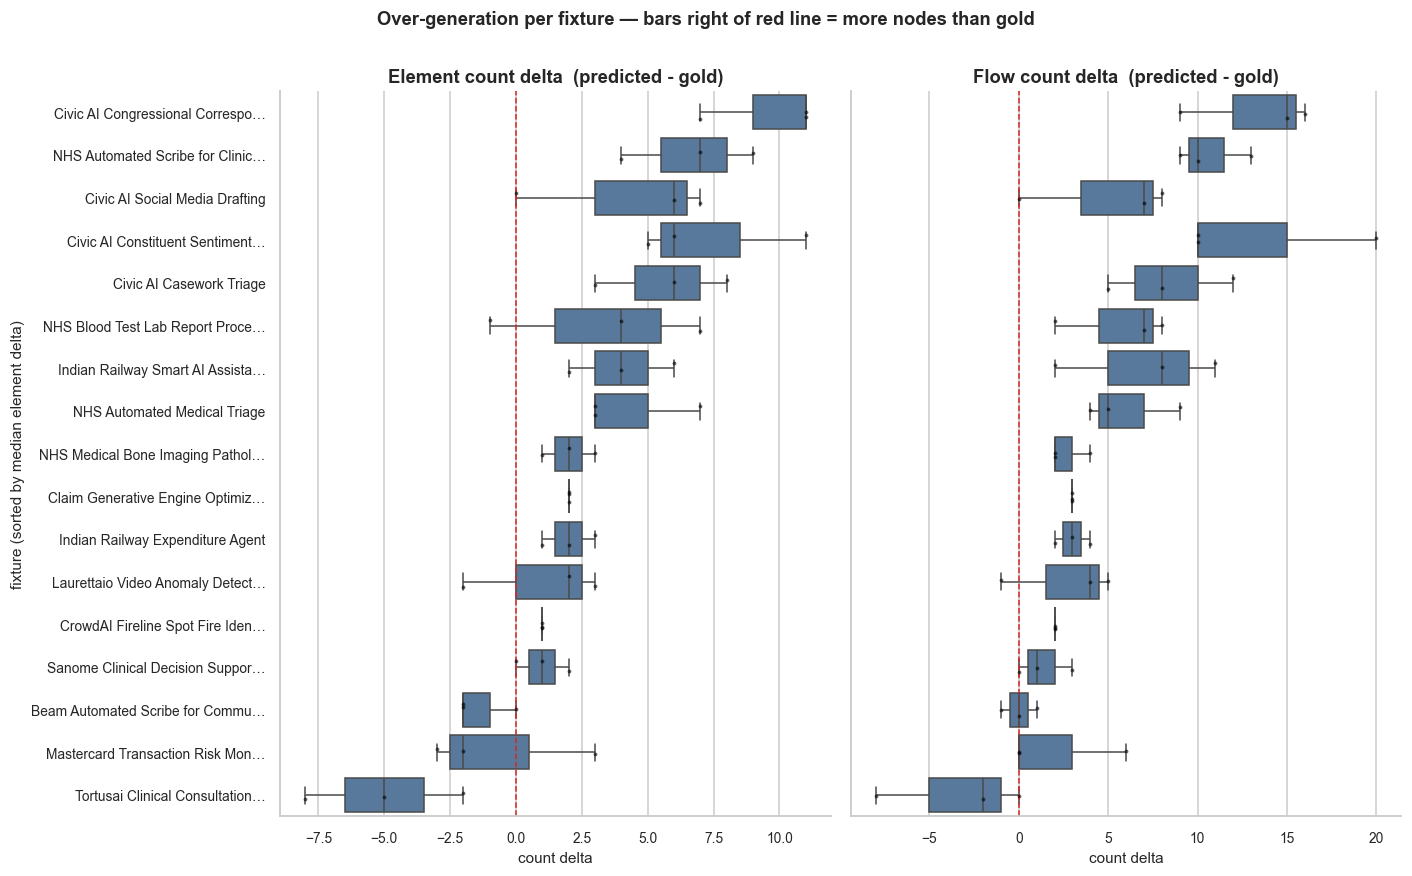

In [8]:
deltas = df.groupby("process_name")[["element_count_delta", "flow_count_delta", "gold_elements", "gold_flows"]].mean()
deltas["element_ratio"] = (deltas["gold_elements"] + deltas["element_count_delta"]) / deltas["gold_elements"]
display(deltas.round(2))

# One-sample t-test: is the mean element delta significantly different from 0?
t_el = stats.ttest_1samp(df["element_count_delta"], 0.0)
t_fl = stats.ttest_1samp(df["flow_count_delta"], 0.0)
print(f"\nElement delta: mean={df['element_count_delta'].mean():.2f}, t={t_el.statistic:.2f}, p={t_el.pvalue:.4f}")
print(f"Flow delta:    mean={df['flow_count_delta'].mean():.2f}, t={t_fl.statistic:.2f}, p={t_fl.pvalue:.4f}")

# Sort fixtures by median element delta so the eye reads top->bottom as "most over-generated".
order_pn = (df.groupby("process_name")["element_count_delta"].median()
              .sort_values(ascending=False).index.tolist())
order = [short_name(p) for p in order_pn]

fig, axes = plt.subplots(1, 2, figsize=(13, max(6, 0.35 * len(order_pn) + 2)), sharey=True)

for ax, col, title in [
    (axes[0], "element_count_delta", "Element count delta  (predicted - gold)"),
    (axes[1], "flow_count_delta",   "Flow count delta  (predicted - gold)"),
]:
    sns.boxplot(data=df, y="fixture", x=col, order=order, ax=ax,
                color="#4c78a8", fliersize=3, linewidth=1)
    sns.stripplot(data=df, y="fixture", x=col, order=order, ax=ax,
                  color="black", size=2.5, alpha=0.6, jitter=0.15)
    ax.axvline(0, color="#d62728", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("count delta")
    ax.set_ylabel("")

axes[0].set_ylabel("fixture (sorted by median element delta)")
fig.suptitle("Over-generation per fixture — bars right of red line = more nodes than gold", y=1.0, fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## H3 - Does fidelity scale with workflow complexity?

**Claim:** As gold workflow size grows, fidelity degrades. We test both axes separately: shape (`structural_similarity`, `type_distribution_similarity`) and meaning (`name_semantic_similarity`, `aligned_type_accuracy`) against gold element count.

**Why it matters:** Tells you *which* axis breaks on large workflows — a shape collapse implicates the single-call generation strategy (it loses the topology of big graphs), while a meaning collapse implicates the ontology prompt / few-shot anchors. Opposite remedies. The 32-element Tortusai swatch is the stress case.

Spearman gold_elements vs structural_similarity           : rho=0.423  p=0.0020
Spearman gold_elements vs type_distribution_similarity    : rho=0.113  p=0.4298
Spearman gold_elements vs name_semantic_similarity        : rho=0.215  p=0.1294
Spearman gold_elements vs aligned_type_accuracy           : rho=-0.348  p=0.0125


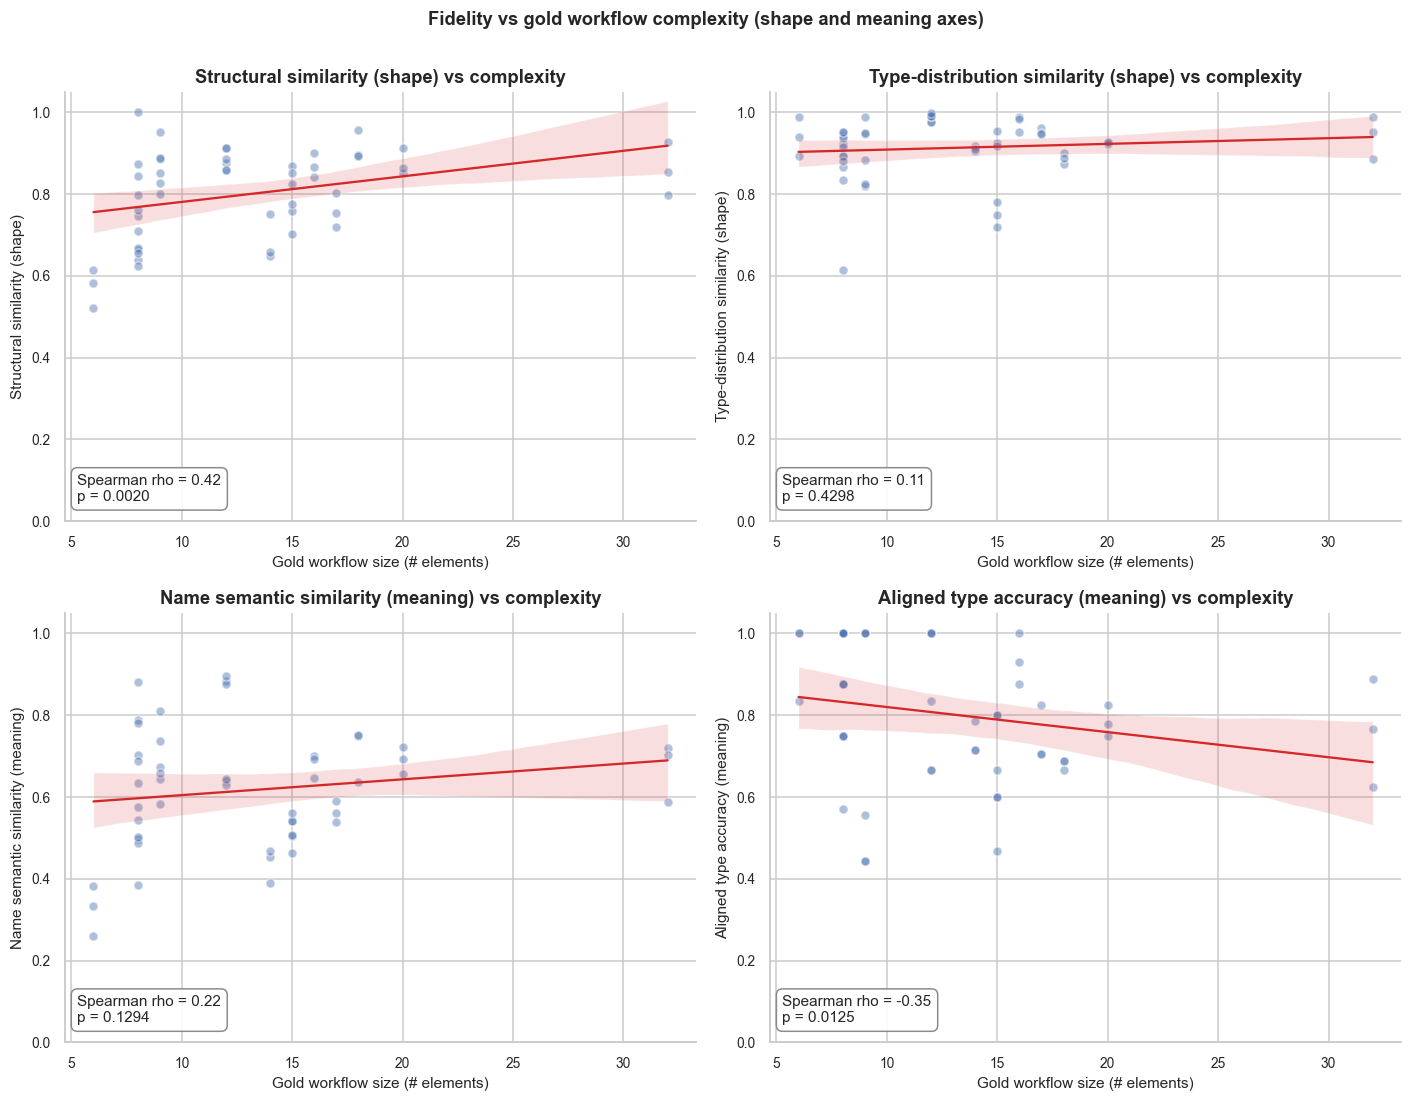

In [9]:
# Fidelity vs complexity, one panel per axis-representative metric.
complexity_metrics = present(
    ["structural_similarity", "type_distribution_similarity",
     "name_semantic_similarity", "aligned_type_accuracy"],
    df,
)
labels = {
    "structural_similarity": "Structural similarity (shape)",
    "type_distribution_similarity": "Type-distribution similarity (shape)",
    "name_semantic_similarity": "Name semantic similarity (meaning)",
    "aligned_type_accuracy": "Aligned type accuracy (meaning)",
}

n = len(complexity_metrics)
ncol = 2
nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 5 * nrow), squeeze=False)
axes = axes.ravel()

for ax, ycol in zip(axes, complexity_metrics):
    sub = df[["gold_elements", ycol]].dropna()
    rho, p = stats.spearmanr(sub["gold_elements"], sub[ycol])
    sns.regplot(data=sub, x="gold_elements", y=ycol, ax=ax,
                scatter_kws={"alpha": 0.45, "s": 35, "edgecolor": "white"},
                line_kws={"color": "#d62728", "linewidth": 1.5})
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Gold workflow size (# elements)")
    ax.set_ylabel(labels.get(ycol, ycol))
    ax.set_title(f"{labels.get(ycol, ycol)} vs complexity")
    ax.text(0.02, 0.04, f"Spearman rho = {rho:.2f}\np = {p:.4f}",
            transform=ax.transAxes, fontsize=10, va="bottom",
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="grey", alpha=0.9))
    print(f"Spearman gold_elements vs {ycol:32s}: rho={rho:.3f}  p={p:.4f}")

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle("Fidelity vs gold workflow complexity (shape and meaning axes)",
             fontsize=12, fontweight="bold", y=1.0)
plt.tight_layout()
plt.show()

## H4 - Are the traces actually good?

A high similarity score doesn't prove much on its own. Because every Fabric trace is built from the same small set of element types, even two *unrelated* workflows already look fairly alike - so a score near 1.0 might just mean "this is a valid Fabric trace," not "this is the *right* trace." We therefore ask two concrete questions instead of trusting the raw number.

**1. Is Weaver closer to the right workflow than to a random one?**
We compare every gold trace against every *other* gold trace (unrelated, but still valid) and call the average score **chance**. Then we check how far Weaver sits above chance. Barely above chance = weak evidence. Far above chance = Weaver genuinely captured *this specific* workflow.

**2. Does Weaver match published tools?**
We put its scores next to a recent state-of-the-art BPMN generation pipeline (Matei et al., 2026) that uses the same metrics. Matching it is our external yardstick for "good."

We report each dimension on its own and never average them into a single "fidelity" number - they sit on different scales, so one combined score would be misleading.

*How to read the table below:* **observed** = Weaver vs the correct gold; **null_mean** = the chance level (unrelated traces); **z_above_null** = how many standard deviations above chance (higher = stronger evidence); **gap_closed** = how much of the distance from chance to a perfect match Weaver covers.

,dimension,observed,null_mean,null_sd,z_above_null,gap_closed
0,Structural,0.801,0.729,0.136,0.530,0.266
1,Type-distribution,0.913,0.865,0.087,0.550,0.354
2,Name semantic,0.617,0.234,0.096,4.011,0.500
3,Name+type semantic,0.652,0.353,0.110,2.713,0.461
4,Aligned type acc.,0.799,0.424,0.179,2.095,0.651


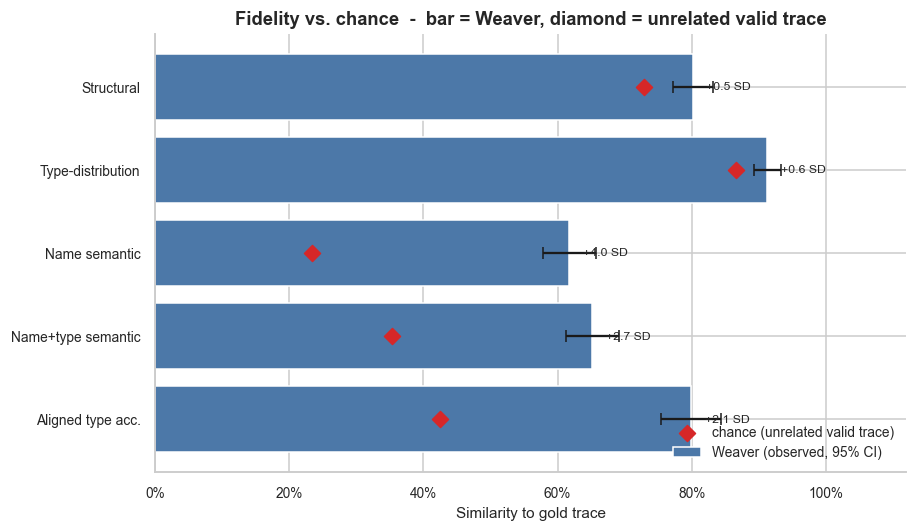

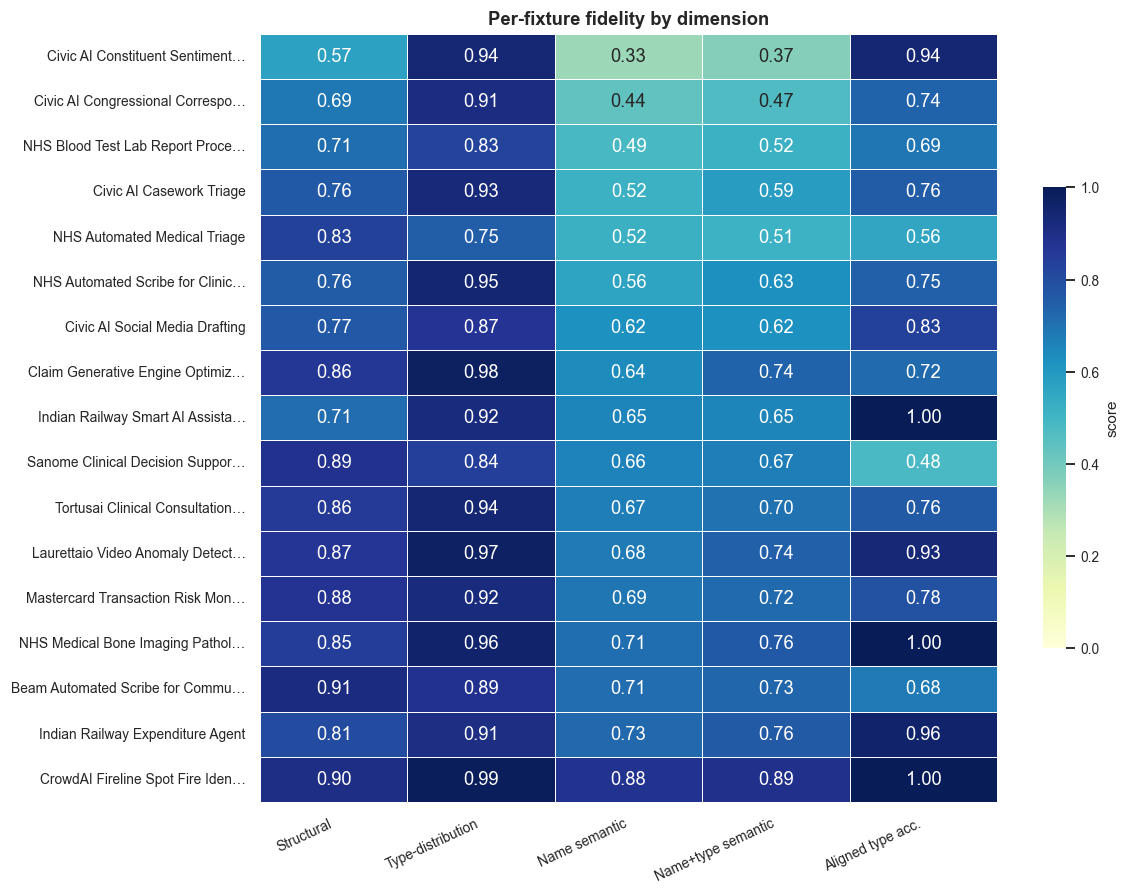

In [10]:
# --- Absolute fidelity #1: distance above chance (gold-vs-gold null) ---
import sys
sys.path.insert(0, str(REPO_ROOT))
from collections import Counter
from services.telemetry import (
    _structural_similarity, _type_distribution_similarity, _semantic_alignment,
)

gold_traces = [w["assistant"] for w in gold]  # all 20, for a richer null

def _five(pred, g):
    pc = Counter(e["type"] for e in pred["elements"])
    gc = Counter(e["type"] for e in g["elements"])
    sem = _semantic_alignment(pred["elements"], g["elements"])
    return {
        "structural_similarity": _structural_similarity(pred, g),
        "type_distribution_similarity": _type_distribution_similarity(pc, gc),
        "name_semantic_similarity": sem["name_semantic_similarity"],
        "name_type_semantic_similarity": sem["name_type_semantic_similarity"],
        "aligned_type_accuracy": sem["aligned_type_accuracy"],
    }

null_df = pd.DataFrame([
    _five(gold_traces[i], gold_traces[j])
    for i in range(len(gold_traces)) for j in range(len(gold_traces)) if i != j
])

DIMS = ["structural_similarity", "type_distribution_similarity",
        "name_semantic_similarity", "name_type_semantic_similarity", "aligned_type_accuracy"]
NICE = {"structural_similarity": "Structural", "type_distribution_similarity": "Type-distribution",
        "name_semantic_similarity": "Name semantic", "name_type_semantic_similarity": "Name+type semantic",
        "aligned_type_accuracy": "Aligned type acc."}

rows = []
for m in DIMS:
    o = df[m].dropna().astype(float); n = null_df[m].dropna().astype(float)
    om, nm, ns = o.mean(), n.mean(), n.std(ddof=1)
    rows.append({"dimension": NICE[m], "observed": om, "null_mean": nm, "null_sd": ns,
                 "z_above_null": (om - nm) / ns if ns else np.nan,
                 "gap_closed": (om - nm) / (1 - nm) if (1 - nm) else np.nan,
                 "ci": 1.96 * o.sem()})
base = pd.DataFrame(rows)
display(base.drop(columns="ci").round(3))

fig, ax = plt.subplots(figsize=(8.5, 0.7 * len(base) + 1.5))
y = np.arange(len(base))
ax.barh(y, base["observed"], xerr=base["ci"], color="#4c78a8", edgecolor="white",
        capsize=4, label="Weaver (observed, 95% CI)")
ax.scatter(base["null_mean"], y, color="#d62728", marker="D", s=55, zorder=3,
           label="chance (unrelated valid trace)")
for yi, (o, nm, z) in enumerate(zip(base["observed"], base["null_mean"], base["z_above_null"])):
    ax.annotate(f"+{z:.1f} SD", (max(o, nm) + 0.02, yi), va="center", fontsize=8)
ax.set_yticks(y); ax.set_yticklabels(base["dimension"]); ax.invert_yaxis()
ax.set_xlim(0, 1.12); ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.set_xlabel("Similarity to gold trace")
ax.set_title("Fidelity vs. chance  -  bar = Weaver, diamond = unrelated valid trace")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

# Per-fixture detail (no cross-dimension ranking implied).
per_fix = df.groupby("process_name")[DIMS].mean().sort_values("name_semantic_similarity")
per_fix.index = [short_name(p) for p in per_fix.index]
per_fix.columns = [NICE[c] for c in DIMS]
fig, ax = plt.subplots(figsize=(1.4 * len(DIMS) + 4, 0.4 * len(per_fix) + 1.5))
sns.heatmap(per_fix, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1,
            linewidths=0.4, linecolor="white", cbar_kws={"label": "score", "shrink": 0.6}, ax=ax)
ax.set_title("Per-fixture fidelity by dimension"); ax.set_xlabel(""); ax.set_ylabel("")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
plt.tight_layout(); plt.show()

### Benchmark: how does Weaver compare to published tools?

Weaver's scores beside Matei et al. (2026)'s BPMN pipeline, on the four dimensions both define the same way. Weaver makes a *single* LLM call to produce a Fabric trace; their pipeline runs *six* stages to produce BPMN. Landing in the same range while being much simpler is the point.

,Weaver (gpt-5-mini),GPT-4o,Gemini-2.5-flash,Gemini-2.5-pro
Structural,0.801,0.805,0.810,0.817
Type-distribution,0.913,0.911,0.903,0.930
Name semantic,0.617,0.617,0.626,0.626
Name+type semantic,0.652,0.700,0.701,0.702


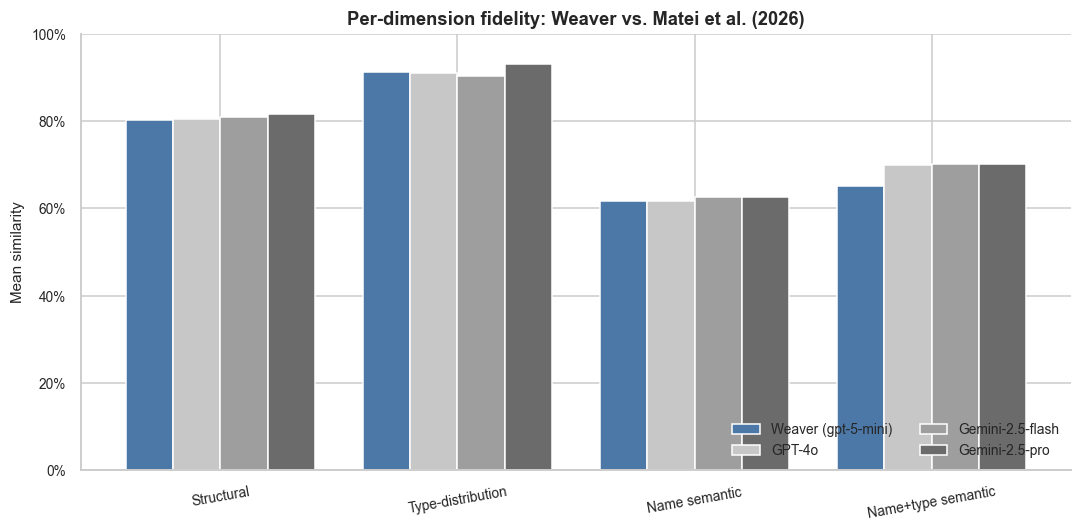

Weaver aligned_type_accuracy = 0.799  (comparable band to Matei 'Type Semantic' 0.79-0.81)


In [11]:
# --- Absolute fidelity #2: benchmark vs Matei et al. (2026), Tables 2-4 ---
matei = pd.DataFrame({
    "Structural":         {"GPT-4o": 0.805, "Gemini-2.5-flash": 0.810, "Gemini-2.5-pro": 0.817},
    "Type-distribution":  {"GPT-4o": 0.911, "Gemini-2.5-flash": 0.903, "Gemini-2.5-pro": 0.930},
    "Name semantic":      {"GPT-4o": 0.617, "Gemini-2.5-flash": 0.626, "Gemini-2.5-pro": 0.626},
    "Name+type semantic": {"GPT-4o": 0.700, "Gemini-2.5-flash": 0.701, "Gemini-2.5-pro": 0.702},
}).T  # index = dimension, columns = their models

shared = ["structural_similarity", "type_distribution_similarity",
          "name_semantic_similarity", "name_type_semantic_similarity"]
weaver = {NICE[m]: df[m].dropna().mean() for m in shared}
bench = matei.copy()
bench.insert(0, "Weaver (gpt-5-mini)", [weaver[d] for d in matei.index])
display(bench.round(3))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(bench)); w = 0.2
cols = list(bench.columns)
colors = {"Weaver (gpt-5-mini)": "#4c78a8", "GPT-4o": "#c7c7c7",
          "Gemini-2.5-flash": "#9e9e9e", "Gemini-2.5-pro": "#6b6b6b"}
for k, c in enumerate(cols):
    ax.bar(x + (k - 1.5) * w, bench[c].values, w, label=c,
           color=colors.get(c, "#ccc"), edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(bench.index, rotation=10)
ax.set_ylim(0, 1.0); ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.set_ylabel("Mean similarity")
ax.set_title("Per-dimension fidelity: Weaver vs. Matei et al. (2026)")
ax.legend(loc="lower right", ncol=2)
plt.tight_layout(); plt.show()

print("Weaver aligned_type_accuracy = %.3f  (comparable band to Matei 'Type Semantic' 0.79-0.81)"
      % df["aligned_type_accuracy"].dropna().mean())

## H5 - Is N=3 enough? (run-to-run variance)

**Claim:** Coefficient of variation (stdev / mean) is small enough on structural and reference metrics that N=3 gives a stable per-fixture estimate.

**Why it matters:** Methodological defense for the dissertation. If CV is high, you need bigger N on the full 20-system run.

,total_tokens,latency_ms,num_elements,num_flows,structural_similarity,type_distribution_similarity,name_semantic_similarity,aligned_type_accuracy
Civic AI Social Media Drafting,0.077,0.174,0.307,0.335,0.263,0.051,0.360,0.087
NHS Blood Test Lab Report Proce…,0.135,0.252,0.357,0.235,0.076,0.224,0.198,0.149
Tortusai Clinical Consultation…,0.101,0.524,0.111,0.124,0.077,0.056,0.108,0.174
Indian Railway Smart AI Assista…,0.107,0.279,0.167,0.306,0.163,0.041,0.183,0.000
Civic AI Constituent Sentiment…,0.057,0.115,0.241,0.315,0.083,0.050,0.190,0.102
Laurettaio Video Anomaly Detect…,0.140,0.255,0.156,0.172,0.035,0.020,0.043,0.067
Civic AI Casework Triage,0.097,0.159,0.122,0.144,0.081,0.020,0.041,0.102
Mastercard Transaction Risk Mon…,0.132,0.171,0.166,0.151,0.036,0.004,0.048,0.047
NHS Automated Medical Triage,0.019,0.139,0.119,0.120,0.059,0.041,0.098,0.139
Sanome Clinical Decision Suppor…,0.038,0.074,0.100,0.148,0.070,0.041,0.115,0.133


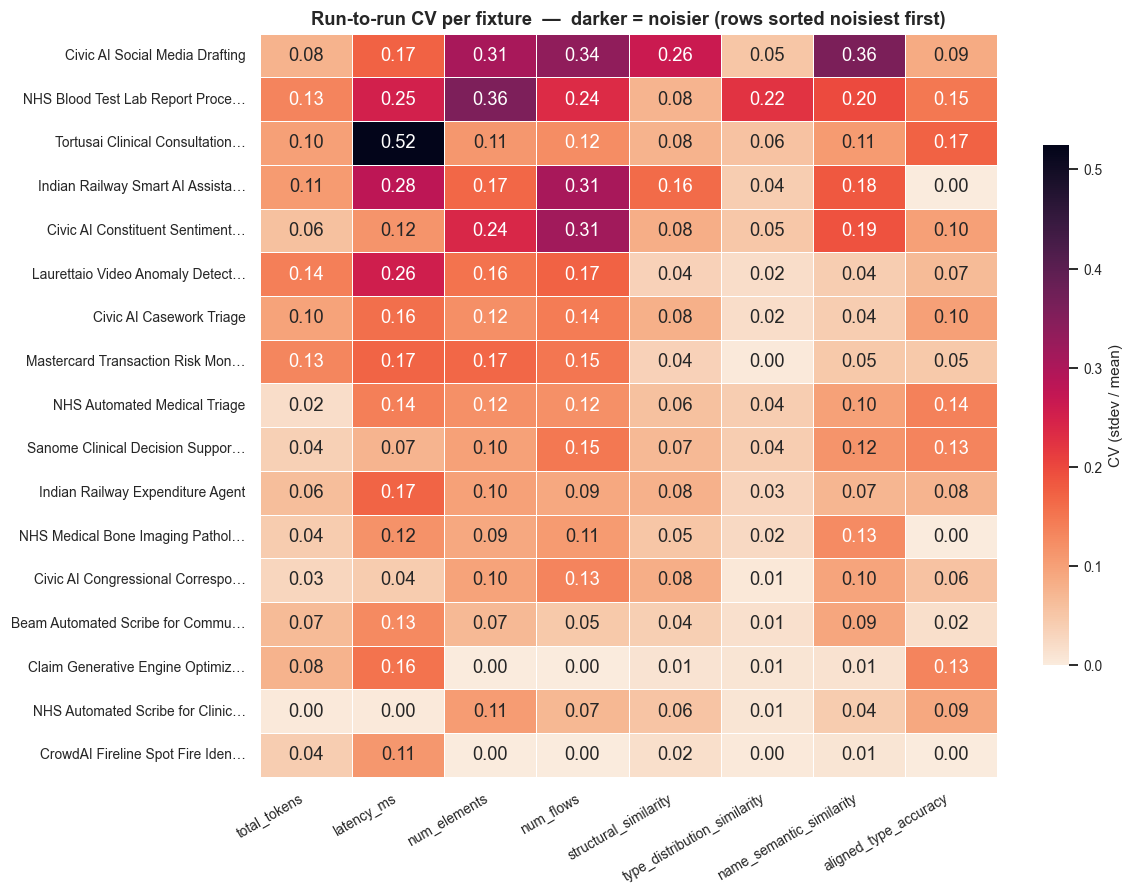

Rule of thumb: CV < 0.1 = very stable, 0.1–0.3 = acceptable, > 0.3 = noisy (need bigger N).


In [12]:
metrics = present([
    "total_tokens", "latency_ms", "num_elements", "num_flows",
    "structural_similarity", "type_distribution_similarity",
    "name_semantic_similarity", "aligned_type_accuracy",
], df)
agg = df.groupby("process_name")[metrics].agg(["mean", "std"])
cv = pd.DataFrame({m: agg[(m, "std")] / agg[(m, "mean")].replace(0, np.nan) for m in metrics})

# Sort fixtures by mean CV (noisiest at top) so the eye lands on the rows that matter.
cv = cv.assign(_mean=cv.mean(axis=1)).sort_values("_mean", ascending=False).drop(columns="_mean")
cv.index = [short_name(p) for p in cv.index]
display(cv.round(3))

fig, ax = plt.subplots(figsize=(11, max(6, 0.4 * len(cv) + 1.5)))
sns.heatmap(
    cv, annot=True, fmt=".2f",
    cmap="rocket_r", vmin=0, vmax=max(0.5, float(np.nanmax(cv.values))),
    linewidths=0.4, linecolor="white",
    cbar_kws={"label": "CV (stdev / mean)", "shrink": 0.7},
    ax=ax,
)
ax.set_title("Run-to-run CV per fixture  —  darker = noisier (rows sorted noisiest first)")
ax.set_xlabel("")
ax.set_ylabel("")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("Rule of thumb: CV < 0.1 = very stable, 0.1–0.3 = acceptable, > 0.3 = noisy (need bigger N).")

## H6 - Completion tokens scale ~linearly with output size

**Claim:** `completion_tokens ~ a + b * (num_elements + num_flows)`. Prompt tokens should be near-constant per fixture (system prompt + 3 few-shots + ~same user msg).

**Why it matters:** Lets you predict token spend on the full 20-system run, and exposes whether MAX_TRACE_TOKENS=16384 has enough headroom.

completion_tokens = 213.8 + 98.3 * (elements+flows)   r^2 = 0.700
prompt_tokens: mean=3791, stdev=30.6


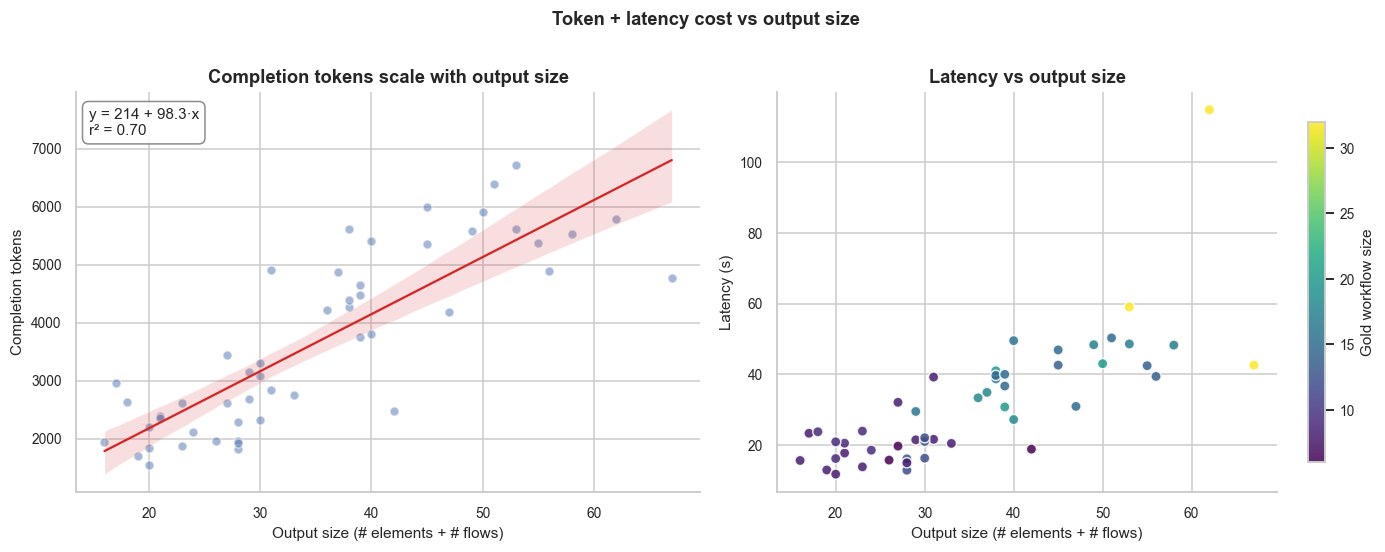

In [13]:
df["output_size"] = df["num_elements"] + df["num_flows"]
fit = stats.linregress(df["output_size"], df["completion_tokens"])
print(f"completion_tokens = {fit.intercept:.1f} + {fit.slope:.1f} * (elements+flows)   r^2 = {fit.rvalue**2:.3f}")
print(f"prompt_tokens: mean={df['prompt_tokens'].mean():.0f}, stdev={df['prompt_tokens'].std():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: token scaling, with the fit equation in a corner annotation.
sns.regplot(
    data=df, x="output_size", y="completion_tokens", ax=axes[0],
    scatter_kws={"alpha": 0.5, "s": 35, "edgecolor": "white"},
    line_kws={"color": "#d62728", "linewidth": 1.5},
)
axes[0].set_xlabel("Output size (# elements + # flows)")
axes[0].set_ylabel("Completion tokens")
axes[0].set_title("Completion tokens scale with output size")
axes[0].text(0.02, 0.96,
             f"y = {fit.intercept:.0f} + {fit.slope:.1f}·x\nr² = {fit.rvalue**2:.2f}",
             transform=axes[0].transAxes, va="top", fontsize=10,
             bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="grey", alpha=0.9))

# Right: latency vs output size, colored by gold_elements (a continuous proxy for fixture
# complexity) instead of by 20-category fixture name — the previous legend was unreadable.
sc = axes[1].scatter(
    df["output_size"], df["latency_ms"] / 1000,
    c=df["gold_elements"], cmap="viridis",
    s=45, alpha=0.85, edgecolor="white",
)
axes[1].set_xlabel("Output size (# elements + # flows)")
axes[1].set_ylabel("Latency (s)")
axes[1].set_title("Latency vs output size")
cbar = fig.colorbar(sc, ax=axes[1], shrink=0.85)
cbar.set_label("Gold workflow size")

fig.suptitle("Token + latency cost vs output size", fontsize=12, fontweight="bold", y=1.0)
plt.tight_layout()
plt.show()

## H7 - Cost: token split, dollar cost, and the cost-fidelity trade-off

**Claim:** Input tokens are near-constant per trace (the fixed system prompt + 3 few-shot exemplars dominate), while output tokens scale with the size of the generated graph; the resulting per-trace dollar cost is small enough to justify GPT-5-mini at the observed fidelity.

**Why it matters:** Following Fettke (2025), cost is reported *alongside* fidelity rather than in isolation — an LLM produces a set of Pareto-optimal variants trading quality against cost, and we use this to defend the model choice. Tokens are logged (not dollars); the conversion happens here at analysis time so the price assumption lives in one editable place.

Mean input tokens:  3791  (sd 31)
Mean output tokens: 3672  (sd 1510)
Mean cost/trace:    $0.0083  (median $0.0076)
Total cost over 51 held-out runs: $0.423


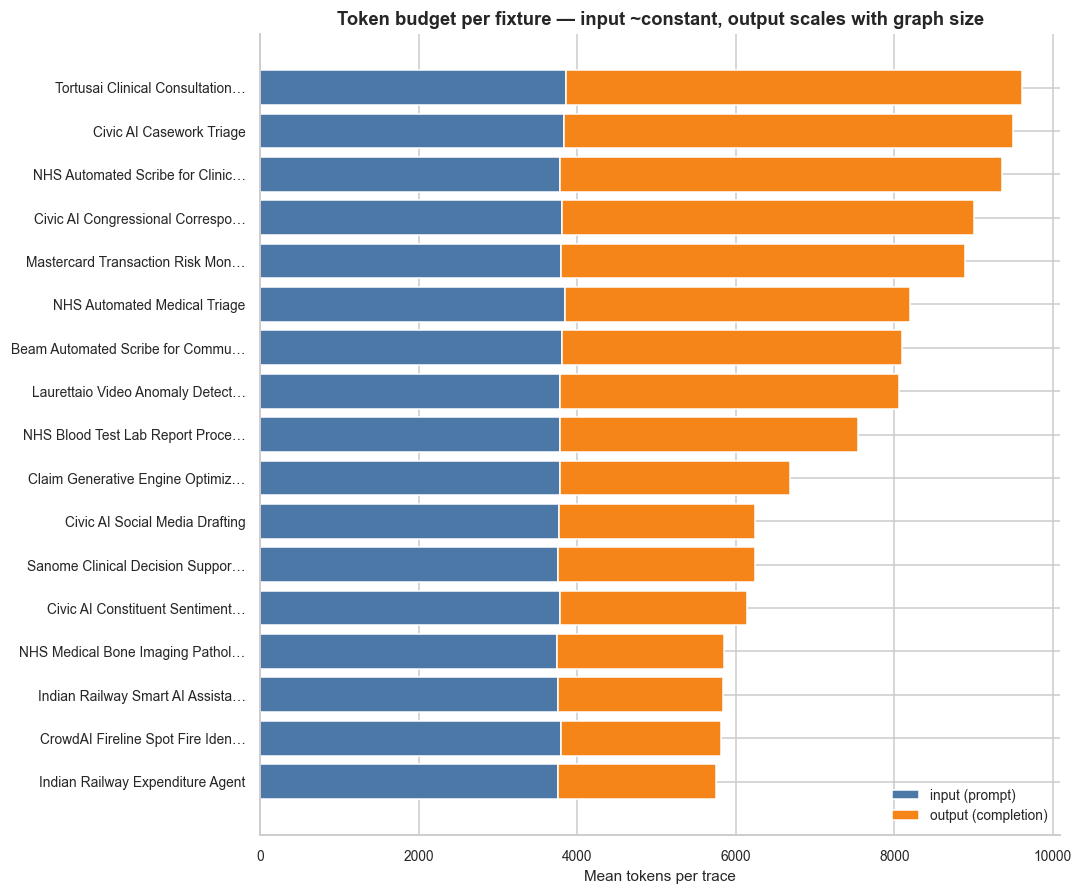

In [14]:
# --- TODO: set current gpt-5-mini prices (USD per 1M tokens) before final run ---
PRICE_INPUT_PER_M = 0.25
PRICE_OUTPUT_PER_M = 2.00

df["cost_usd"] = (
    df["prompt_tokens"] * PRICE_INPUT_PER_M + df["completion_tokens"] * PRICE_OUTPUT_PER_M
) / 1e6

print(f"Mean input tokens:  {df['prompt_tokens'].mean():.0f}  (sd {df['prompt_tokens'].std():.0f})")
print(f"Mean output tokens: {df['completion_tokens'].mean():.0f}  (sd {df['completion_tokens'].std():.0f})")
print(f"Mean cost/trace:    ${df['cost_usd'].mean():.4f}  (median ${df['cost_usd'].median():.4f})")
print(f"Total cost over {len(df)} held-out runs: ${df['cost_usd'].sum():.3f}")

# Input is near-constant (system prompt + 3 few-shots + user msg); output scales with graph size.
tok = df.groupby("process_name")[["prompt_tokens", "completion_tokens"]].mean()
tok = tok.sort_values("completion_tokens")
tok.index = [short_name(p) for p in tok.index]

fig, ax = plt.subplots(figsize=(10, max(5, 0.4 * len(tok) + 1.5)))
ax.barh(tok.index, tok["prompt_tokens"], color="#4c78a8", edgecolor="white", label="input (prompt)")
ax.barh(tok.index, tok["completion_tokens"], left=tok["prompt_tokens"],
        color="#f58518", edgecolor="white", label="output (completion)")
ax.set_xlabel("Mean tokens per trace")
ax.set_title("Token budget per fixture — input ~constant, output scales with graph size")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

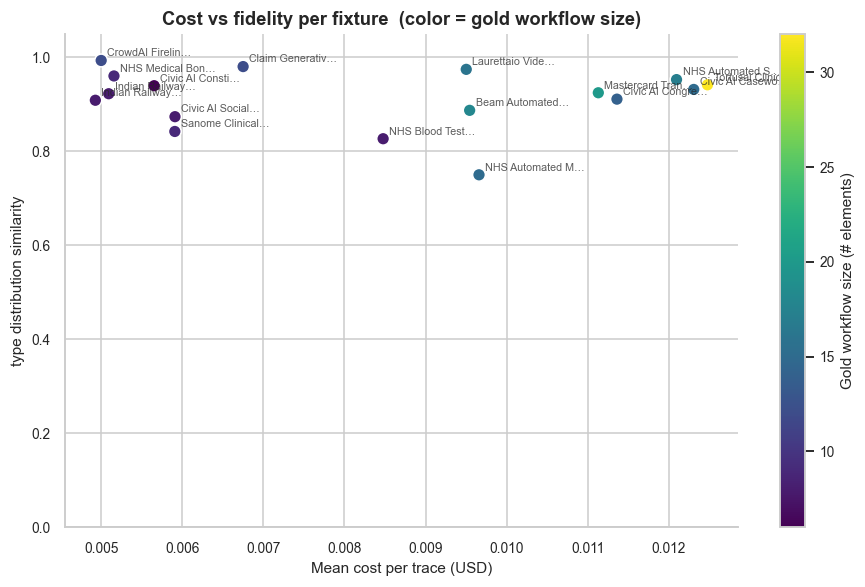

Operating point: mean $0.0083/trace at type_distribution_similarity = 0.913


In [15]:
# Cost vs fidelity. Fettke (2025) argues an LLM yields not one optimum but a set
# of Pareto-optimal variants trading quality against cost — so cost is read
# alongside fidelity. NOTE: with a single model this is an operating-point
# scatter, NOT a true Pareto front (a front needs >=2 models on the same fixtures).
YAXIS = "type_distribution_similarity"  # swap for any fidelity dimension

per = df.groupby("process_name").agg(
    cost_usd=("cost_usd", "mean"),
    total_tokens=("total_tokens", "mean"),
    fidelity=(YAXIS, "mean"),
    gold_elements=("gold_elements", "first"),
).dropna(subset=["fidelity"])

fig, ax = plt.subplots(figsize=(8.5, 5.5))
sc = ax.scatter(per["cost_usd"], per["fidelity"], c=per["gold_elements"],
                cmap="viridis", s=70, edgecolor="white", zorder=3)
for name, row in per.iterrows():
    ax.annotate(short_name(name, 16), (row["cost_usd"], row["fidelity"]),
                fontsize=7, alpha=0.75, xytext=(4, 3), textcoords="offset points")
ax.set_xlabel("Mean cost per trace (USD)")
ax.set_ylabel(YAXIS.replace("_", " "))
ax.set_ylim(0, 1.05)
ax.set_title("Cost vs fidelity per fixture  (color = gold workflow size)")
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Gold workflow size (# elements)")
plt.tight_layout()
plt.show()

print(f"Operating point: mean ${per['cost_usd'].mean():.4f}/trace at "
      f"{YAXIS} = {per['fidelity'].mean():.3f}")

## Quick takeaways table

Per-fixture cheat sheet for the dissertation chapter. Mean values across N runs.

In [16]:
agg_spec = dict(
    n_runs=("run_idx", "count"),
    gold_elements=("gold_elements", "first"),
    pred_elements_mean=("num_elements", "mean"),
    element_delta_mean=("element_count_delta", "mean"),
    semantic_pass_rate=("semantic_pass", "mean"),
    structural_sim_mean=("structural_similarity", "mean"),
    type_dist_sim_mean=("type_distribution_similarity", "mean"),
    total_tokens_mean=("total_tokens", "mean"),
    latency_s_mean=("latency_ms", lambda s: s.mean() / 1000),
)
# Only include meaning metrics if the semantic deps were available at run time.
if df["name_semantic_similarity"].notna().any():
    agg_spec["name_sem_mean"] = ("name_semantic_similarity", "mean")
    agg_spec["aligned_type_acc_mean"] = ("aligned_type_accuracy", "mean")

out = df.groupby("process_name").agg(**agg_spec).round(2)
out

,n_runs,gold_elements,pred_elements_mean,element_delta_mean,semantic_pass_rate,structural_sim_mean,type_dist_sim_mean,total_tokens_mean,latency_s_mean,name_sem_mean,aligned_type_acc_mean
process_name,,,,,,,,,,,
Beam Automated Scribe for Community Care Worker,3,18,16.67,-1.33,1.00,0.91,0.89,8102.33,31.84,0.71,0.68
Civic AI Casework Triage,3,15,20.67,5.67,1.00,0.76,0.93,9504.00,44.64,0.52,0.76
Civic AI Congressional Correspondence,3,14,23.67,9.67,0.67,0.69,0.91,9011.33,41.50,0.44,0.74
Civic AI Constituent Sentiment Analysis,3,6,13.33,7.33,1.00,0.57,0.94,6137.00,18.12,0.33,0.94
Civic AI Social Media Drafting,3,8,12.33,4.33,1.00,0.77,0.87,6249.67,19.60,0.62,0.83
Claim Generative Engine Optimization for Webpages,3,12,14.00,2.00,1.00,0.86,0.98,6689.00,19.81,0.64,0.72
CrowdAI Fireline Spot Fire Identification,3,12,13.00,1.00,1.00,0.90,0.99,5820.00,14.46,0.88,1.00
Indian Railway Expenditure Agent,3,8,10.00,2.00,1.00,0.81,0.91,5750.00,14.86,0.73,0.96
Indian Railway Smart AI Assistant,3,8,12.00,4.00,1.00,0.71,0.92,5837.67,15.76,0.65,1.00
